In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_curve, auc
from sklearn.base import clone

In [ ]:
# Load data

df = pd.read_csv("FINAL_dataset.csv")

print("Data awal:", len(df))

# Data clean

# Hapus views = 0
df = df[df["views_6h"] > 0]

# Delete data with anomalies
df = df[~(
    (df["likes_6h"] == 0) &
    (df["views_6h"] > 10000)
)]

# Hapus duplicate
df = df.drop_duplicates(subset=["video_id"])

print("Setelah cleaning:", len(df))

Data awal: 856
Setelah cleaning: 856


In [ ]:
# Feature engineering

df["engagement_rate_6h"] = (
    (df["likes_6h"] + df["comments_6h"]) /
    (df["views_6h"] + 1)
)

df["views_velocity"] = (
    df["views_6h"] / 6
)

In [ ]:
# Labeling

threshold = df["views_24h"].quantile(0.8)

df["viral"] = (
    df["views_24h"] > threshold
).astype(int)

print("\nClass Distribution")
print(df["viral"].value_counts())



Class Distribution
viral
0    685
1    171
Name: count, dtype: int64


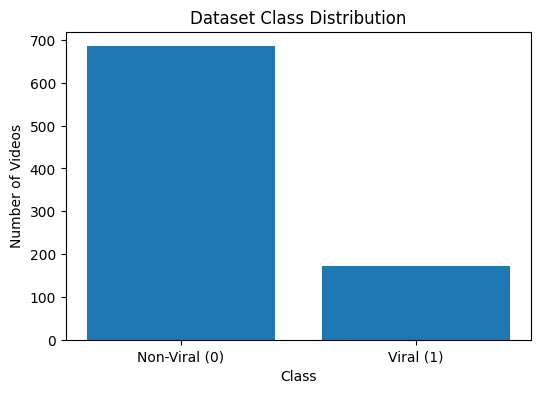

In [ ]:
# Dataset distribution

class_counts = df["viral"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Non-Viral (0)", "Viral (1)"],
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Videos")
plt.title("Dataset Class Distribution")
plt.show()

In [ ]:
# List features & target

X = df[
    [
        "views_6h",
        "likes_6h",
        "comments_6h",
        "engagement_rate_6h",
        "views_velocity"
    ]
]

y = df["viral"]

In [ ]:
# Stratitfied K-fold karena distribusi data imbalance

skf = StratifiedKFold(
    n_splits=5,      # jumlah split/fold
    shuffle=True,
    random_state=42
)

In [ ]:
# Buat model

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ])
}


In [ ]:
# eval metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

In [ ]:
# Cross validation (dari K-fold)

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=skf,
        scoring=scoring,
        n_jobs=1
    )

    results.append({

        "Model": name,

        "Accuracy":
            scores["test_accuracy"].mean(),

        "Precision":
            scores["test_precision"].mean(),

        "Recall":
            scores["test_recall"].mean(),

        "F1-Score":
            scores["test_f1"].mean(),

        "AUC-ROC":
            scores["test_roc_auc"].mean()

    })

In [ ]:
# result table

results_df = pd.DataFrame(results)

results_df = results_df.round(3)

print("\n=== Cross Validation Results ===")
print(results_df)

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)


=== Cross Validation Results ===
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.947      0.951   0.784     0.854    0.979
1        Random Forest     0.940      0.888   0.807     0.842    0.971
2              XGBoost     0.943      0.871   0.836     0.852    0.971


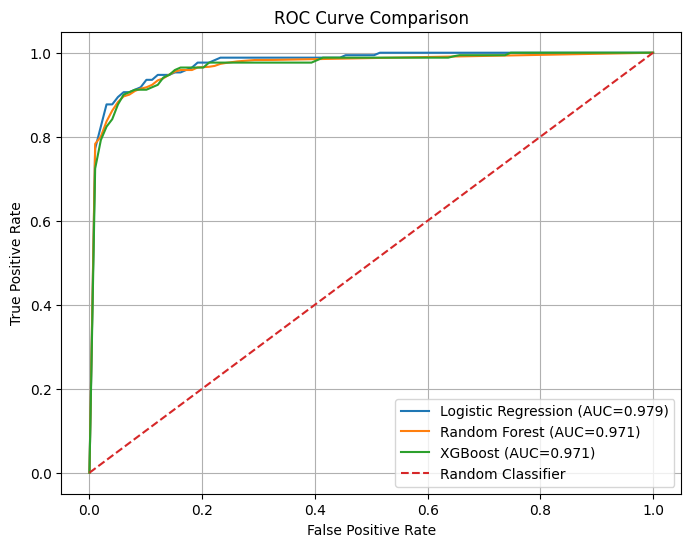

In [ ]:
# ROC curve (mean dari K-fold)

plt.figure(figsize=(8,6))

for name, model in models.items():

    mean_fpr = np.linspace(0, 1, 100)

    tprs = []
    aucs = []

    for train_idx, test_idx in skf.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        clf = clone(model)

        clf.fit(X_train, y_train)

        y_prob = clf.predict_proba(X_test)[:,1]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

        interp_tpr = np.interp(
            mean_fpr,
            fpr,
            tpr
        )

        interp_tpr[0] = 0

        tprs.append(interp_tpr)

        aucs.append(
            auc(fpr, tpr)
        )

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = np.mean(aucs)

    plt.plot(
        mean_fpr,
        mean_tpr,
        label=f"{name} (AUC={mean_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [15]:
print(results_df.columns)
print(results_df)

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'], dtype='object')
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.947      0.951   0.784     0.854    0.979
1        Random Forest     0.940      0.888   0.807     0.842    0.971
2              XGBoost     0.943      0.871   0.836     0.852    0.971


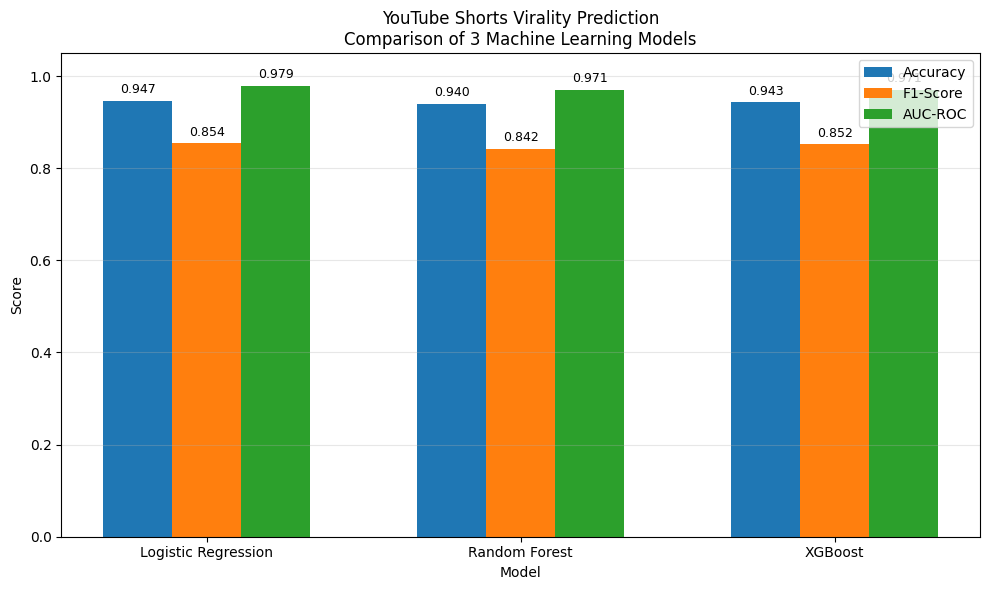

In [ ]:
# bar chart untuk compare tiap model

metrics = ["Accuracy", "F1-Score", "AUC-ROC"]

plt.figure(figsize=(10, 6))

x = np.arange(len(results_df["Model"]))
width = 0.22

for i, metric in enumerate(metrics):
    bars = plt.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric
    )

    #nilai di atas bar
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Model")
plt.ylabel("Score")
plt.title(
    "YouTube Shorts Virality Prediction\n"
    "Comparison of 3 Machine Learning Models"
)

plt.xticks(
    x + width,
    results_df["Model"]
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "youtube_shorts_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()